In [3]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("outputs/linear")

## 1. Load all runs

Each run consists of:

- one `.npz` file with arrays,
- one `_config.json` file with hyperparameters.


In [6]:
def load_run(npz_path: Path) -> dict:
    config_path = npz_path.with_name(npz_path.stem + "_config.json")
    with open(config_path) as f:
        config = json.load(f)

    data = np.load(npz_path, allow_pickle=True)

    traj_ids = sorted({
        int(m.group(1))
        for key in data.files
        if (m := re.match(r"traj(\d+)_losses", key))
    })

    run = {
        "name": npz_path.stem,
        "npz_path": npz_path,
        "config": config,
        "data": data,
        "traj_ids": traj_ids,
    }
    return run


runs = [load_run(p) for p in sorted(RESULTS_DIR.glob("*.npz"))]
len(runs), [r["name"] for r in runs]


(7,
 ['linear_adam512_lr0.1_200000iters',
  'linear_adamw512_lr0.1_200000iters',
  'linear_gd_lr0.1_200000iters',
  'linear_gd_lr0.1_wd0.1_200000iters',
  'linear_muon512_lr0.1_200000iters',
  'linear_sgd32_lr0.1_200000iters',
  'linear_sgd512_lr0.1_200000iters'])

In [7]:
def run_label(run: dict) -> str:
    c = run["config"]
    opt = c.get("optimizer", "?")
    lr = c.get("lr", "?")
    bs = "full" if opt == "gd" else c.get("batch_size", "?")
    wd = c.get("weight_decay", 0.0)
    if wd:
        return f"{opt}, bs={bs}, lr={lr}, wd={wd}"
    return f"{opt}, bs={bs}, lr={lr}"


summary_rows = []
for run in runs:
    c = run["config"]
    data = run["data"]

    for traj in run["traj_ids"]:
        losses = data[f"traj{traj}_losses"]
        irelnorms = data[f"traj{traj}_irelnorms"]

        summary_rows.append({
            "run": run["name"],
            "label": run_label(run),
            "traj": traj,
            "optimizer": c.get("optimizer"),
            "batch_size": "full" if c.get("optimizer") == "gd" else c.get("batch_size"),
            "lr": c.get("lr"),
            "weight_decay": c.get("weight_decay"),
            "target": c.get("target"),
            "n_iters": c.get("n_iters"),
            "final_loss": float(losses[-1]),
            "min_loss": float(losses.min()),
            "final_irelnorm": float(irelnorms[-1]),
            "min_irelnorm": float(irelnorms.min()),
            "init_irelnorm": float(irelnorms[0]),
        })

summary = pd.DataFrame(summary_rows)
summary.sort_values(["final_irelnorm", "final_loss"])


,run,label,traj,optimizer,batch_size,lr,weight_decay,target,n_iters,final_loss,min_loss,final_irelnorm,min_irelnorm,init_irelnorm
3,linear_gd_lr0.1_wd0.1_200000iters,"gd, bs=full, lr=0.1, wd=0.1",0,gd,full,0.1,0.1,linear,200000,0.000893,1.106525e-05,0.000890,0.000090,4.427655
8,linear_sgd32_lr0.1_200000iters,"sgd, bs=32, lr=0.1",3,sgd,32,0.1,0.0,linear,200000,0.007118,1.310207e-06,0.046285,0.041935,4.471912
7,linear_sgd32_lr0.1_200000iters,"sgd, bs=32, lr=0.1",2,sgd,32,0.1,0.0,linear,200000,0.027250,1.053119e-06,0.048919,0.041855,4.472419
9,linear_sgd32_lr0.1_200000iters,"sgd, bs=32, lr=0.1",4,sgd,32,0.1,0.0,linear,200000,0.028611,9.409998e-07,0.050121,0.041406,4.472013
5,linear_sgd32_lr0.1_200000iters,"sgd, bs=32, lr=0.1",0,sgd,32,0.1,0.0,linear,200000,0.022793,7.050429e-07,0.051346,0.042272,4.473274
6,linear_sgd32_lr0.1_200000iters,"sgd, bs=32, lr=0.1",1,sgd,32,0.1,0.0,linear,200000,0.026279,1.559279e-06,0.051708,0.041826,4.472792
13,linear_sgd512_lr0.1_200000iters,"sgd, bs=512, lr=0.1",3,sgd,512,0.1,0.0,linear,200000,0.033927,1.704348e-02,1.680470,1.680438,4.472551
14,linear_sgd512_lr0.1_200000iters,"sgd, bs=512, lr=0.1",4,sgd,512,0.1,0.0,linear,200000,0.031077,1.643319e-02,1.683078,1.683077,4.472744
12,linear_sgd512_lr0.1_200000iters,"sgd, bs=512, lr=0.1",2,sgd,512,0.1,0.0,linear,200000,0.032873,1.698754e-02,1.683489,1.683466,4.472247
11,linear_sgd512_lr0.1_200000iters,"sgd, bs=512, lr=0.1",1,sgd,512,0.1,0.0,linear,200000,0.035284,2.109138e-02,1.686090,1.686090,4.472267


## 2. Loss curves

Use log scale because optimizer differences can be huge and early training often dominates the visual impression.


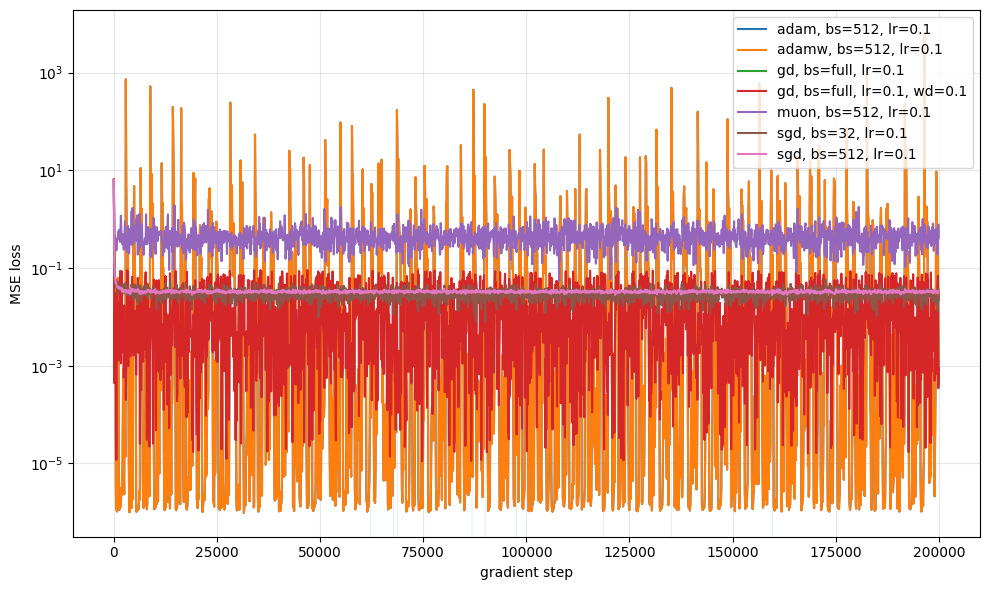

In [8]:
def plot_metric_curves(metric: str, ylabel: str, logy: bool = False, max_points: int = 2000):
    plt.figure(figsize=(10, 6))

    for run in runs:
        data = run["data"]
        label = run_label(run)

        curves = []
        for traj in run["traj_ids"]:
            y = data[f"traj{traj}_{metric}"]
            curves.append(y)

        # Average across trajectories if multiple exist.
        min_len = min(len(c) for c in curves)
        curves = np.stack([c[:min_len] for c in curves])
        mean = curves.mean(axis=0)
        std = curves.std(axis=0)

        # Downsample for readability.
        idx = np.linspace(0, min_len - 1, min(max_points, min_len)).astype(int)
        x = idx
        y = mean[idx]
        s = std[idx]

        plt.plot(x, y, label=label)
        if len(run["traj_ids"]) > 1:
            plt.fill_between(x, y - s, y + s, alpha=0.15)

    plt.xlabel("gradient step")
    plt.ylabel(ylabel)
    if logy:
        plt.yscale("log")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_metric_curves("losses", "MSE loss", logy=True)


## 3. Irrelevant-feature norm curves

This is probably the most important plot for the project.

The training script tracks:

```python
np.linalg.norm(W1[:, r:d])
```

where `W1` is the first-layer weight matrix. Lower means the network is using irrelevant input coordinates less.


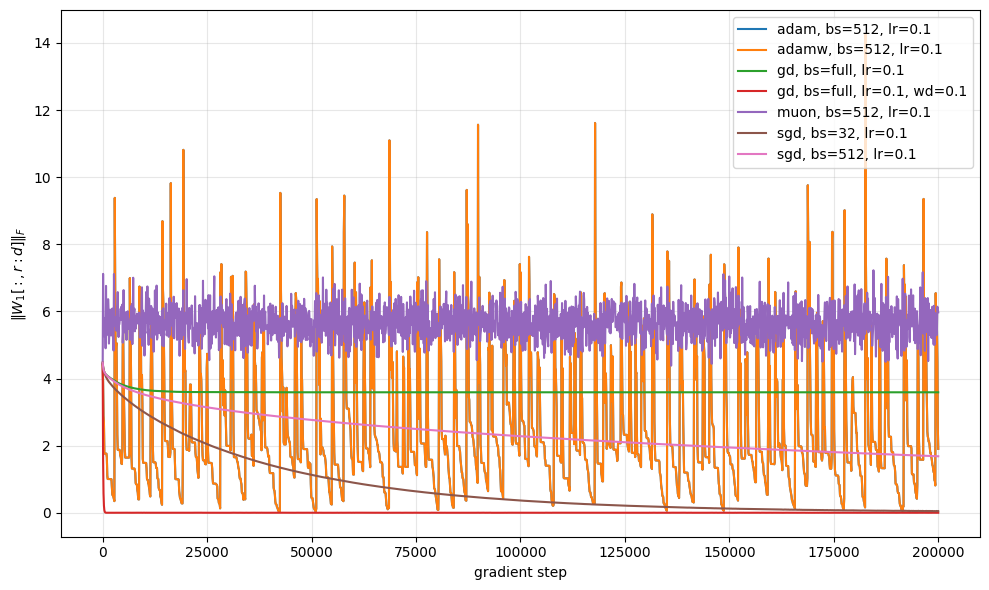

In [9]:
plot_metric_curves("irelnorms", r"$\|W_1[:, r:d]\|_F$", logy=False)


## 4. Final score table

This table helps you quickly see which optimizer finished with low loss and low irrelevant norm.


In [10]:
display(
    summary
    .groupby(["label", "optimizer", "batch_size", "weight_decay"], as_index=False)
    .agg(
        final_loss_mean=("final_loss", "mean"),
        final_loss_std=("final_loss", "std"),
        final_irelnorm_mean=("final_irelnorm", "mean"),
        final_irelnorm_std=("final_irelnorm", "std"),
        min_irelnorm_mean=("min_irelnorm", "mean"),
    )
    .sort_values("final_irelnorm_mean")
)


,label,optimizer,batch_size,weight_decay,final_loss_mean,final_loss_std,final_irelnorm_mean,final_irelnorm_std,min_irelnorm_mean
3,"gd, bs=full, lr=0.1, wd=0.1",gd,full,0.1,0.000893,NaN,0.000890,NaN,0.000090
5,"sgd, bs=32, lr=0.1",sgd,32,0.0,0.022410,0.008815,0.049676,0.002190,0.041859
6,"sgd, bs=512, lr=0.1",sgd,512,0.0,0.034435,0.002986,1.683986,0.002539,1.683967
0,"adam, bs=512, lr=0.1",adam,512,0.0,0.000429,NaN,1.905378,NaN,0.028625
1,"adamw, bs=512, lr=0.1",adamw,512,0.0,0.000429,NaN,1.905378,NaN,0.028625
2,"gd, bs=full, lr=0.1",gd,full,0.0,0.033273,NaN,3.589976,NaN,3.589975
4,"muon, bs=512, lr=0.1",muon,512,0.0,0.408194,NaN,5.973217,NaN,2.585432


## 5. Scatter: final loss vs final irrelevant norm

The ideal region is bottom-left: low loss and low irrelevant-feature norm.

A method that gets low loss but high irrelevant norm fits the data while still relying on irrelevant directions.


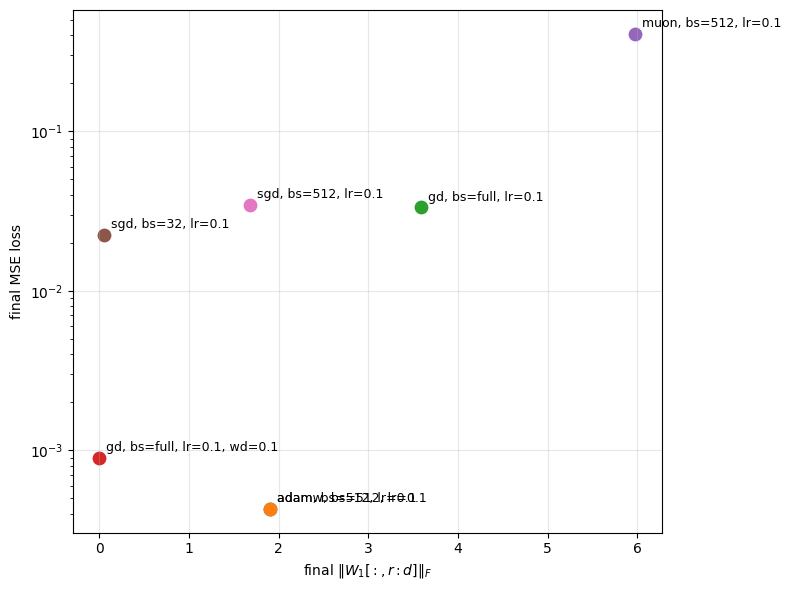

In [11]:
plt.figure(figsize=(8, 6))

agg = (
    summary
    .groupby("label", as_index=False)
    .agg(final_loss=("final_loss", "mean"),
         final_irelnorm=("final_irelnorm", "mean"))
)

for _, row in agg.iterrows():
    plt.scatter(row["final_irelnorm"], row["final_loss"], s=80)
    plt.annotate(row["label"], (row["final_irelnorm"], row["final_loss"]),
                 xytext=(5, 5), textcoords="offset points", fontsize=9)

plt.xlabel(r"final $\|W_1[:, r:d]\|_F$")
plt.ylabel("final MSE loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Relevant vs irrelevant first-layer weight norms

For each final model, compare the norm of the first-layer columns corresponding to relevant features versus irrelevant features.

This is a more interpretable version of the support-learning diagnostic.


In [12]:
def first_layer_split_norms(run: dict, traj: int = 0, state: str = "post") -> tuple[float, float]:
    c = run["config"]
    r = c["r"]
    d = c["d"]
    W1 = run["data"][f"traj{traj}_layer0_{state}"]
    relevant = np.linalg.norm(W1[:, :r])
    irrelevant = np.linalg.norm(W1[:, r:d])
    return float(relevant), float(irrelevant)


rows = []
for run in runs:
    for traj in run["traj_ids"]:
        rel_init, irrel_init = first_layer_split_norms(run, traj, "init")
        rel_post, irrel_post = first_layer_split_norms(run, traj, "post")
        rows.append({
            "label": run_label(run),
            "traj": traj,
            "rel_init": rel_init,
            "irrel_init": irrel_init,
            "rel_post": rel_post,
            "irrel_post": irrel_post,
            "ratio_post_irrel_over_rel": irrel_post / rel_post if rel_post > 0 else np.nan,
        })

split_df = pd.DataFrame(rows)
display(split_df.sort_values("ratio_post_irrel_over_rel"))


,label,traj,rel_init,irrel_init,rel_post,irrel_post,ratio_post_irrel_over_rel
3,"gd, bs=full, lr=0.1, wd=0.1",0,3.425957,4.478588,1.217321,0.000890,0.000731
8,"sgd, bs=32, lr=0.1",3,3.425957,4.478588,1.450721,0.046285,0.031905
7,"sgd, bs=32, lr=0.1",2,3.425957,4.478588,1.486165,0.048919,0.032917
9,"sgd, bs=32, lr=0.1",4,3.425957,4.478588,1.484793,0.050121,0.033756
6,"sgd, bs=32, lr=0.1",1,3.425957,4.478588,1.486423,0.051708,0.034787
5,"sgd, bs=32, lr=0.1",0,3.425957,4.478588,1.451890,0.051346,0.035365
0,"adam, bs=512, lr=0.1",0,3.425957,4.478588,4.598313,1.905379,0.414365
1,"adamw, bs=512, lr=0.1",0,3.425957,4.478588,4.598313,1.905379,0.414365
13,"sgd, bs=512, lr=0.1",3,3.425957,4.478588,1.791438,1.680470,0.938057
14,"sgd, bs=512, lr=0.1",4,3.425957,4.478588,1.790275,1.683078,0.940123


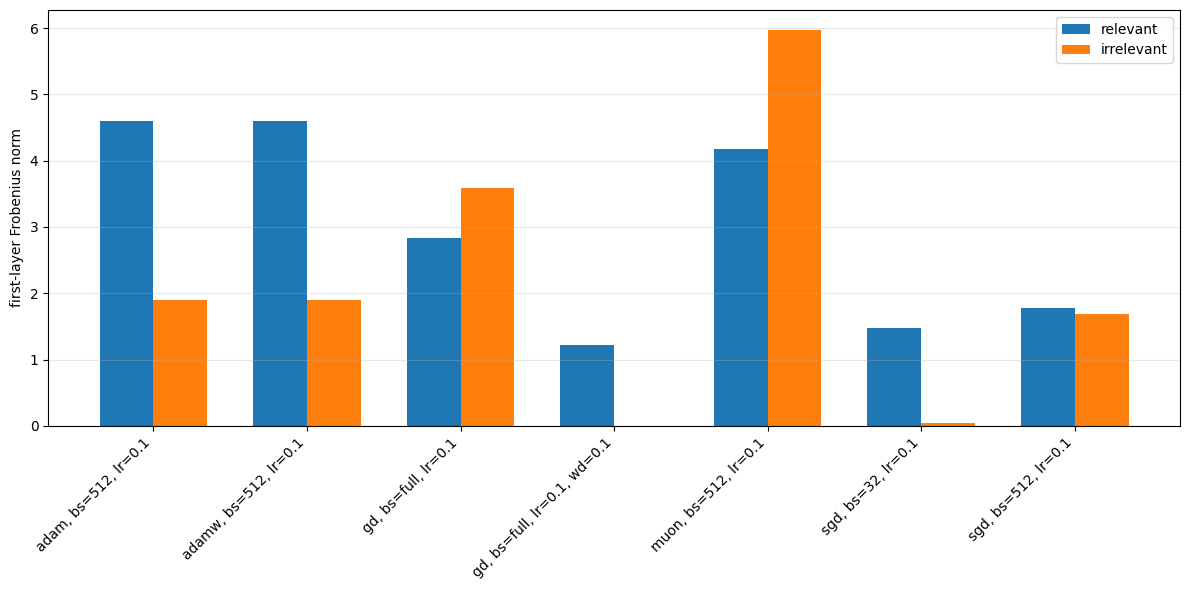

In [13]:
plot_df = (
    split_df
    .groupby("label", as_index=False)
    .agg(rel_post=("rel_post", "mean"),
         irrel_post=("irrel_post", "mean"))
)

x = np.arange(len(plot_df))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, plot_df["rel_post"], width, label="relevant")
plt.bar(x + width/2, plot_df["irrel_post"], width, label="irrelevant")
plt.xticks(x, plot_df["label"], rotation=45, ha="right")
plt.ylabel("first-layer Frobenius norm")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 7. First-layer heatmaps

These show which input coordinates are used by each hidden unit.

Columns `0` to `r-1` are relevant. Columns `r` to `d-1` are irrelevant.


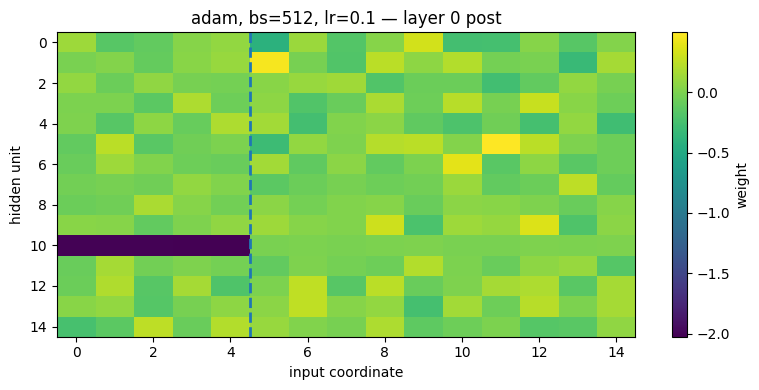

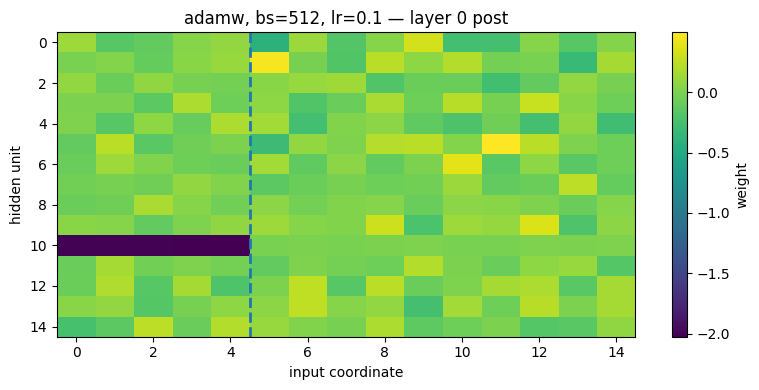

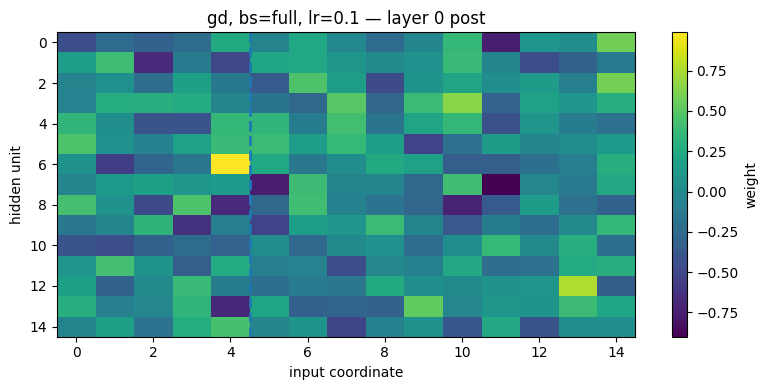

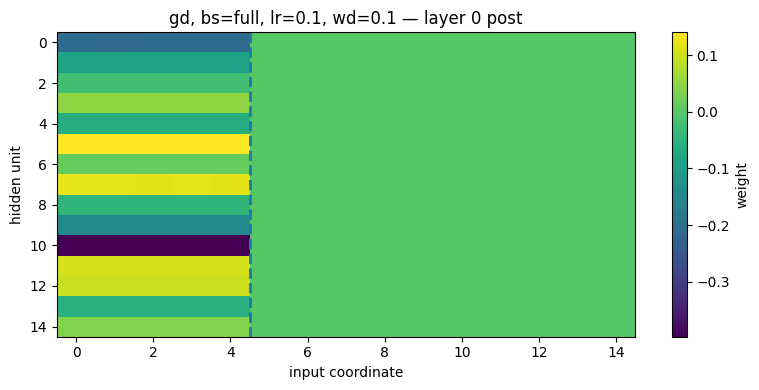

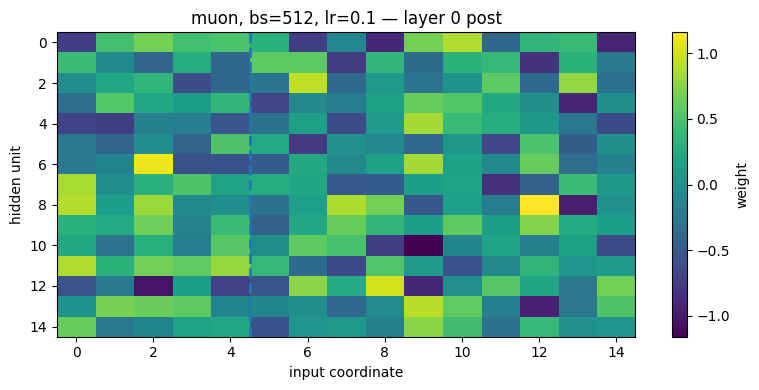

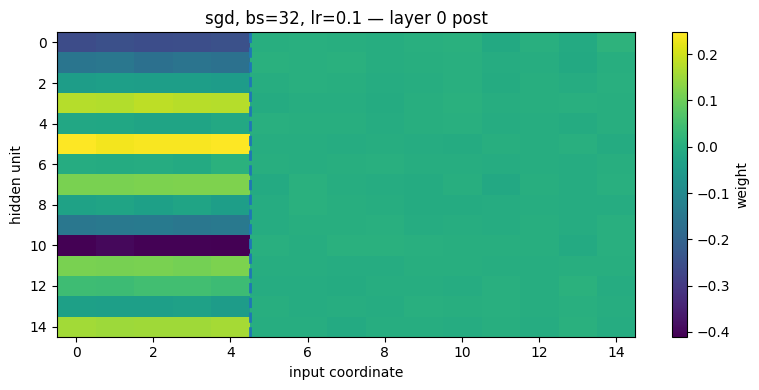

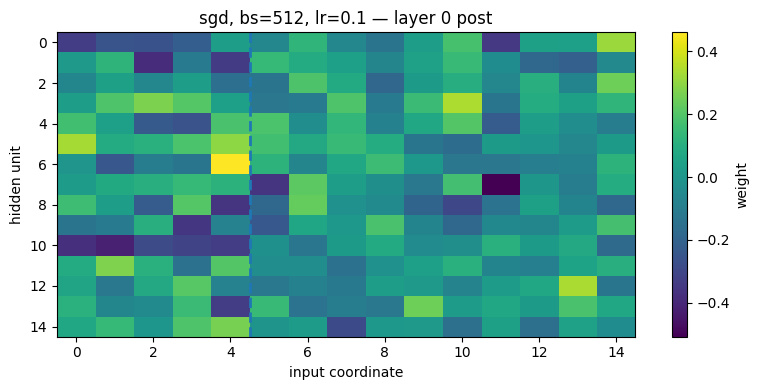

In [14]:
def plot_first_layer_heatmaps(state: str = "post", traj: int = 0):
    for run in runs:
        c = run["config"]
        r = c["r"]
        W1 = run["data"][f"traj{traj}_layer0_{state}"]

        plt.figure(figsize=(8, 4))
        plt.imshow(W1, aspect="auto")
        plt.colorbar(label="weight")
        plt.axvline(r - 0.5, linestyle="--", linewidth=2)
        plt.title(f"{run_label(run)} — layer 0 {state}")
        plt.xlabel("input coordinate")
        plt.ylabel("hidden unit")
        plt.tight_layout()
        plt.show()


plot_first_layer_heatmaps("post", traj=0)


## 8. Singular values of layer matrices

This is useful for the spectral angle of the project: different optimizers may produce different rank structure or implicit compression.

For each layer, we plot singular values at initialization and after training.


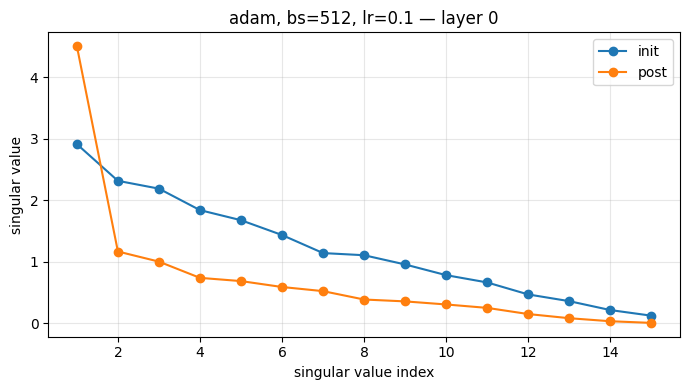

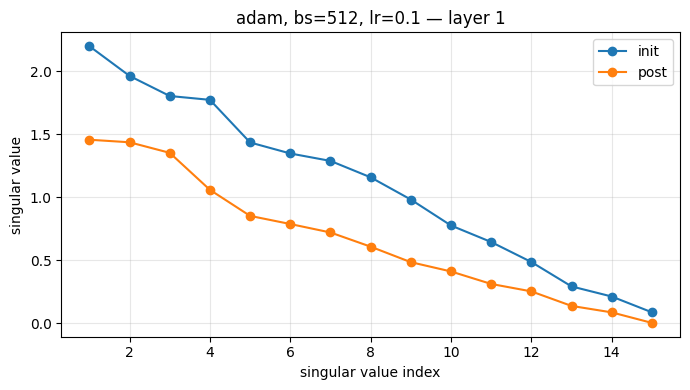

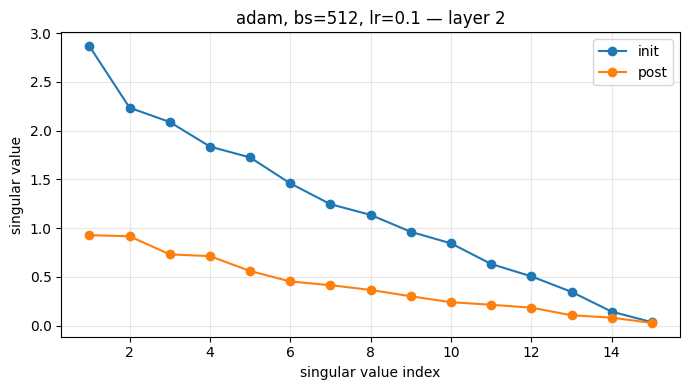

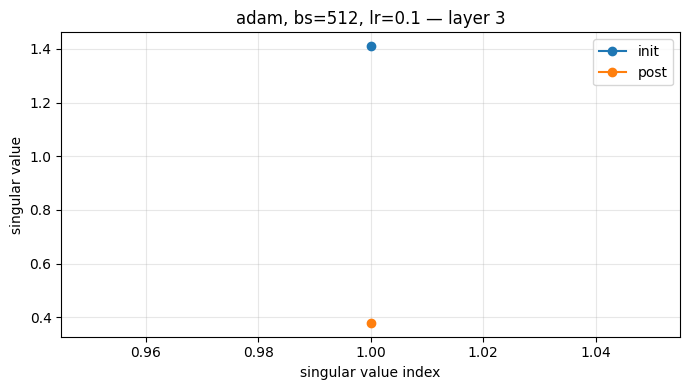

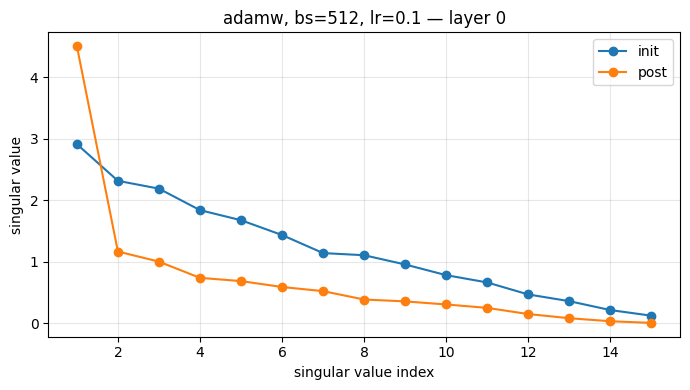

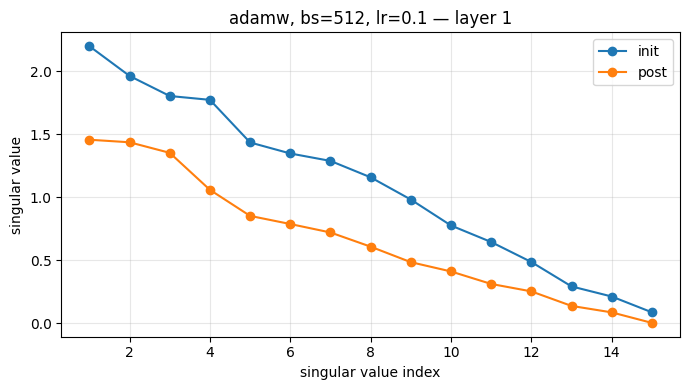

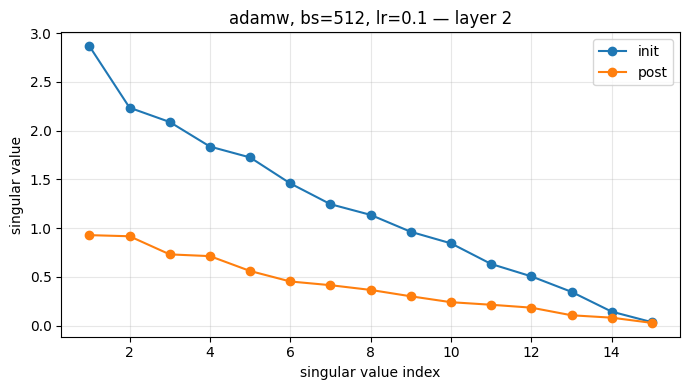

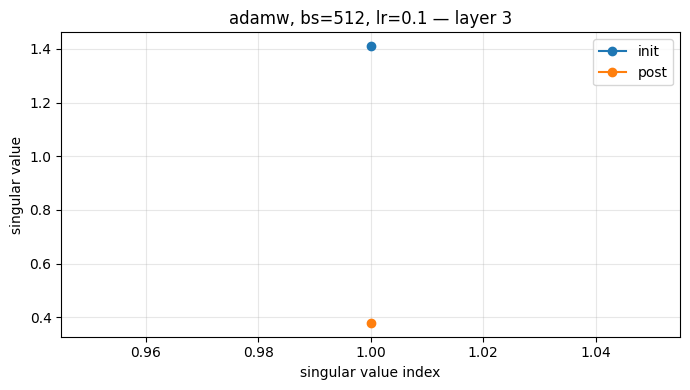

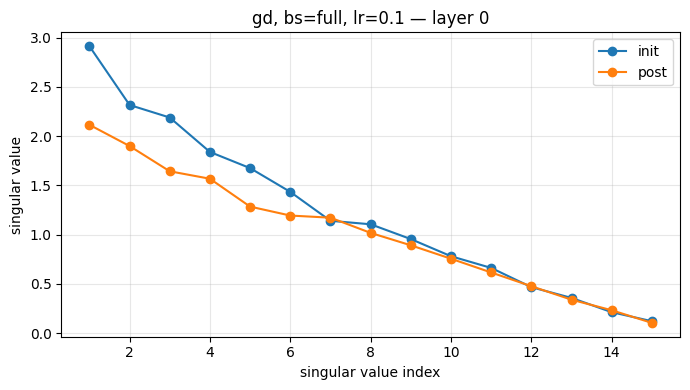

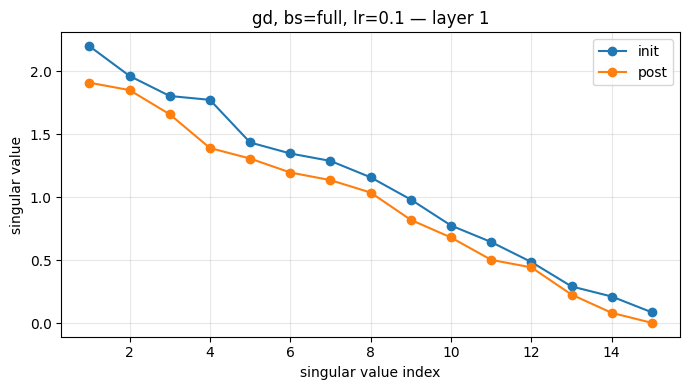

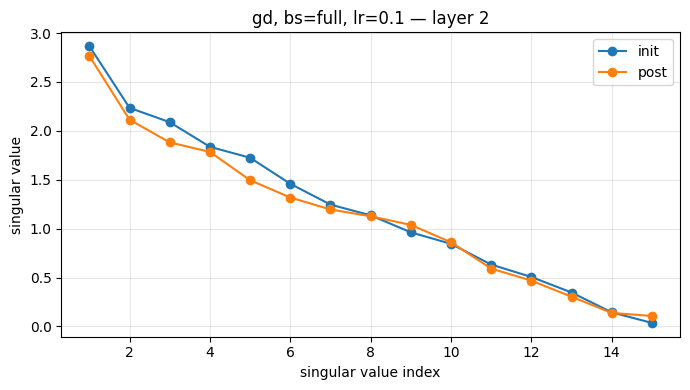

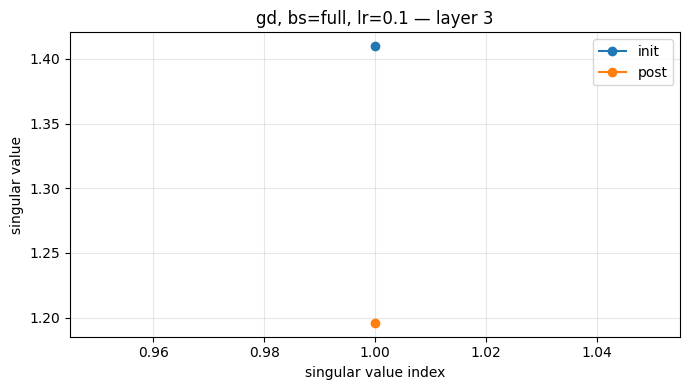

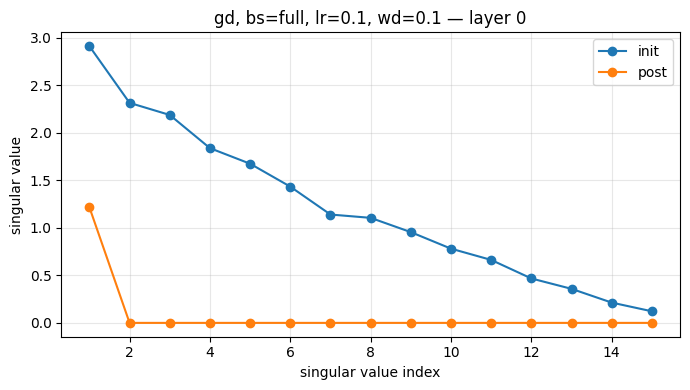

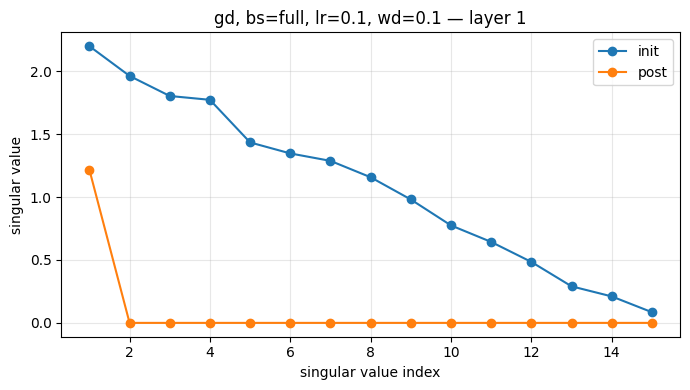

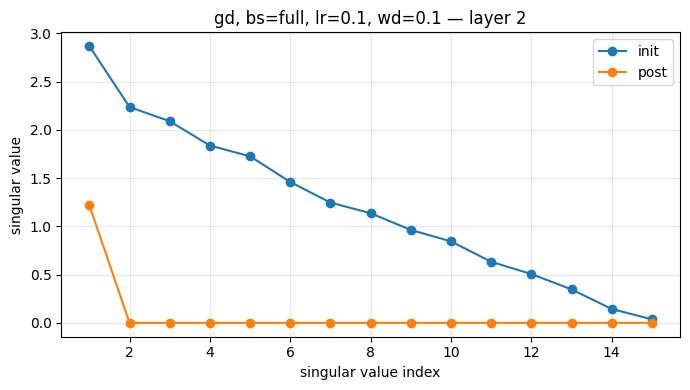

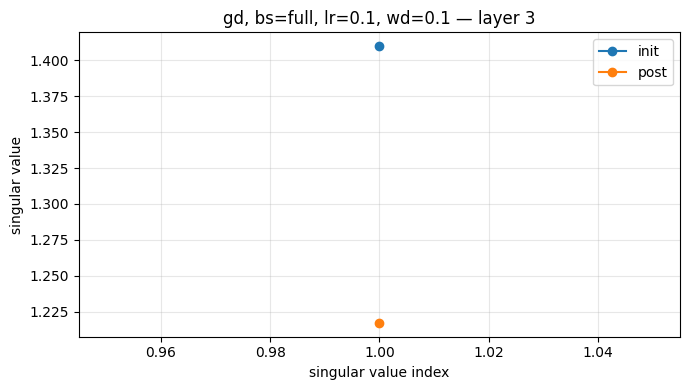

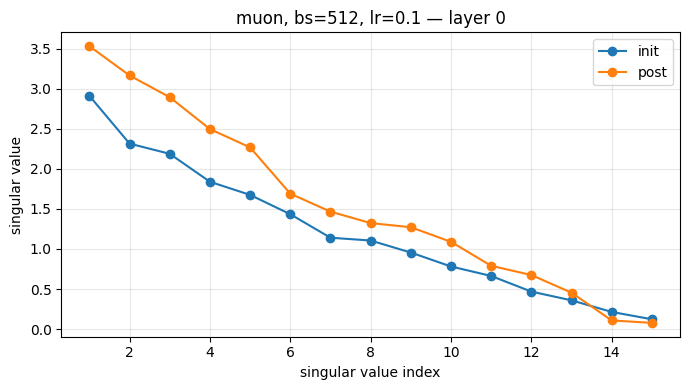

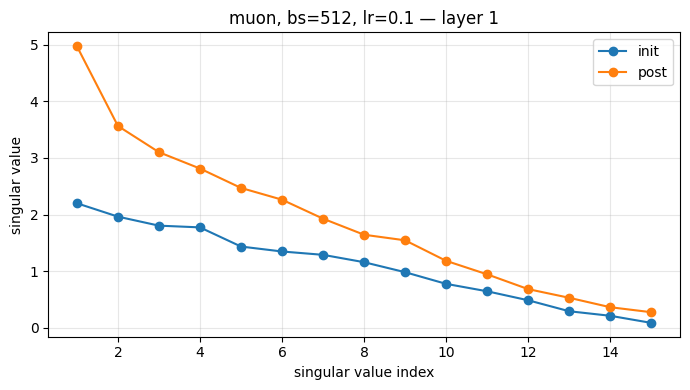

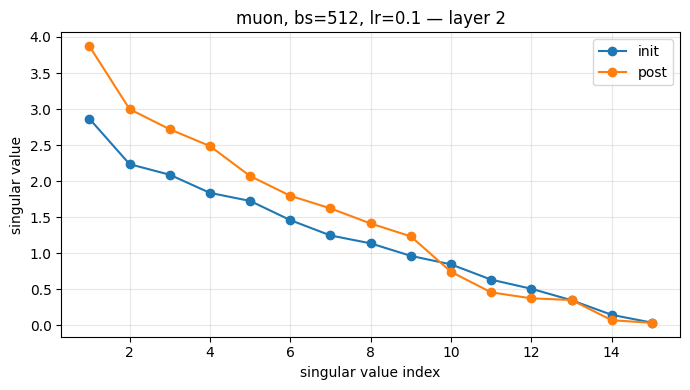

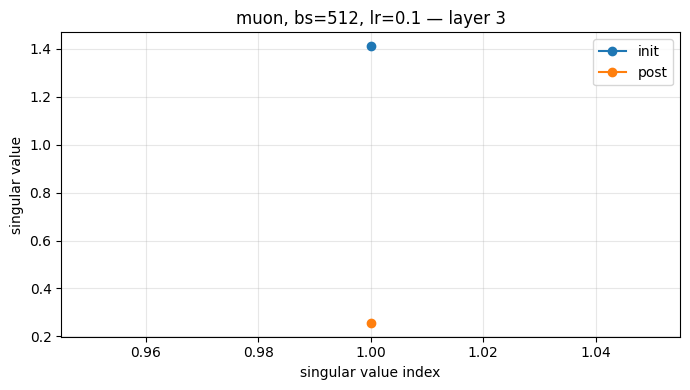

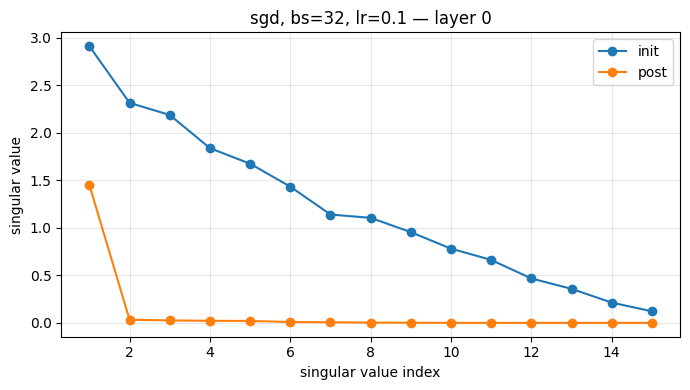

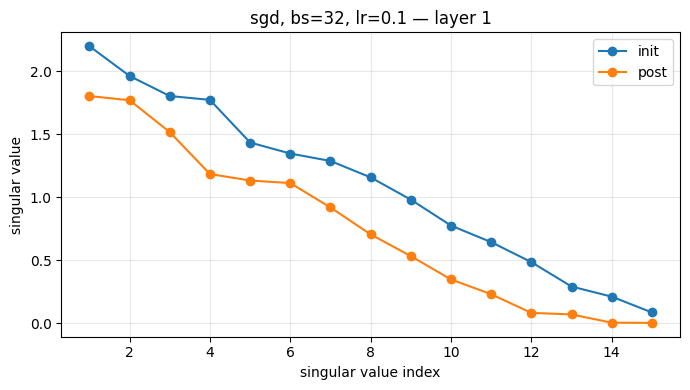

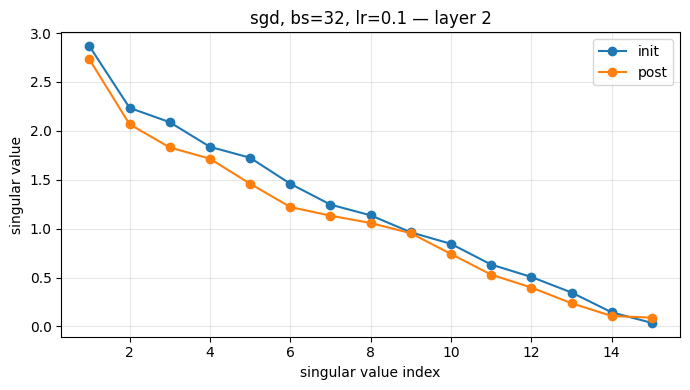

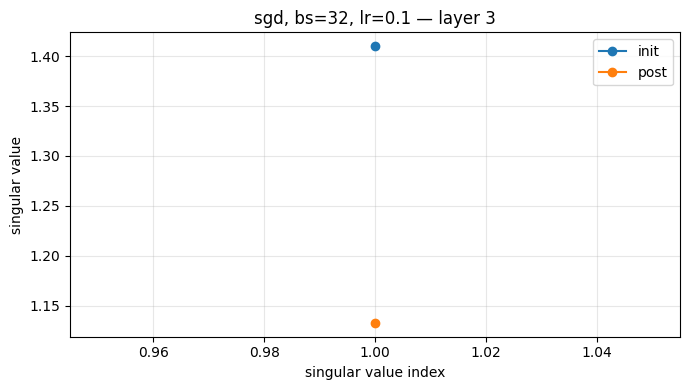

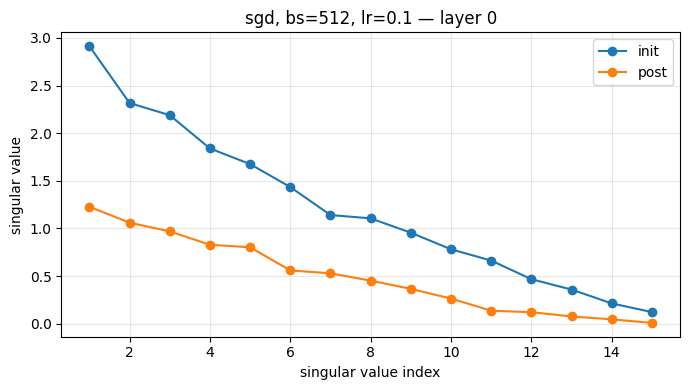

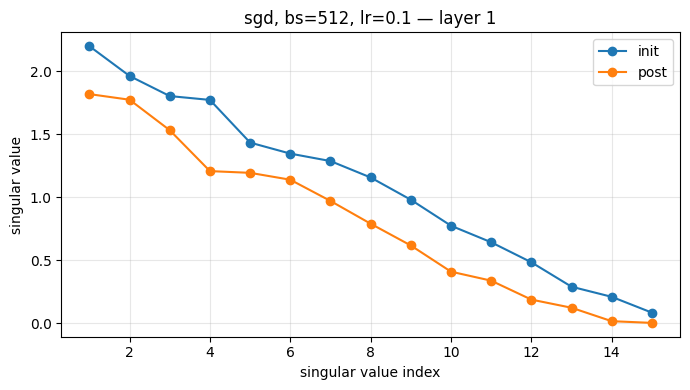

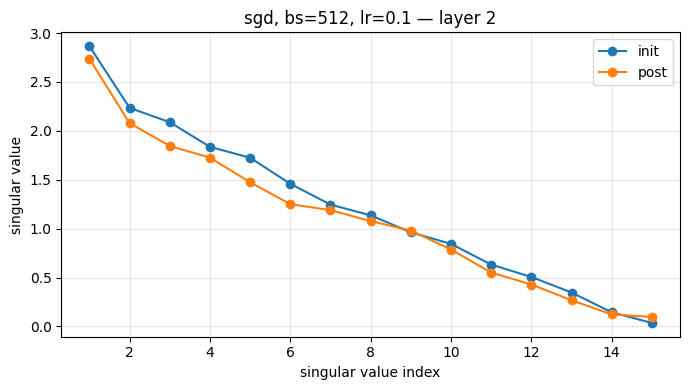

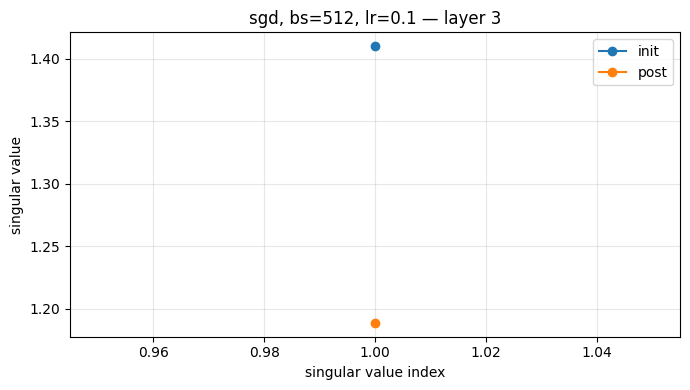

In [15]:
def layer_ids(run: dict) -> list[int]:
    ids = []
    for key in run["data"].files:
        m = re.match(r"traj0_layer(\d+)_post", key)
        if m:
            ids.append(int(m.group(1)))
    return sorted(ids)


def plot_singular_values(traj: int = 0):
    for run in runs:
        ids = layer_ids(run)
        for layer in ids:
            W_init = run["data"][f"traj{traj}_layer{layer}_init"]
            W_post = run["data"][f"traj{traj}_layer{layer}_post"]

            s_init = np.linalg.svd(W_init, compute_uv=False)
            s_post = np.linalg.svd(W_post, compute_uv=False)

            plt.figure(figsize=(7, 4))
            plt.plot(np.arange(1, len(s_init) + 1), s_init, marker="o", label="init")
            plt.plot(np.arange(1, len(s_post) + 1), s_post, marker="o", label="post")
            plt.title(f"{run_label(run)} — layer {layer}")
            plt.xlabel("singular value index")
            plt.ylabel("singular value")
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


plot_singular_values(traj=0)


## 9. Effective rank

A compact spectral summary. Effective rank is high when singular values are spread out, and low when only a few singular directions dominate.


In [16]:
def effective_rank(W: np.ndarray, eps: float = 1e-12) -> float:
    s = np.linalg.svd(W, compute_uv=False)
    p = s / (s.sum() + eps)
    entropy = -(p * np.log(p + eps)).sum()
    return float(np.exp(entropy))


rank_rows = []
for run in runs:
    for traj in run["traj_ids"]:
        for layer in layer_ids(run):
            W_init = run["data"][f"traj{traj}_layer{layer}_init"]
            W_post = run["data"][f"traj{traj}_layer{layer}_post"]
            rank_rows.append({
                "label": run_label(run),
                "traj": traj,
                "layer": layer,
                "eff_rank_init": effective_rank(W_init),
                "eff_rank_post": effective_rank(W_post),
                "delta_eff_rank": effective_rank(W_post) - effective_rank(W_init),
            })

rank_df = pd.DataFrame(rank_rows)
display(rank_df.sort_values(["layer", "eff_rank_post"]))


,label,traj,layer,eff_rank_init,eff_rank_post,delta_eff_rank
12,"gd, bs=full, lr=0.1, wd=0.1",0,0,11.884899,1.000004,-10.884895
36,"sgd, bs=32, lr=0.1",4,0,11.884899,1.493265,-10.391634
24,"sgd, bs=32, lr=0.1",1,0,11.884899,1.496112,-10.388787
28,"sgd, bs=32, lr=0.1",2,0,11.884899,1.500057,-10.384842
32,"sgd, bs=32, lr=0.1",3,0,11.884899,1.506162,-10.378738
20,"sgd, bs=32, lr=0.1",0,0,11.884899,1.513243,-10.371656
0,"adam, bs=512, lr=0.1",0,0,11.884899,7.587856,-4.297043
4,"adamw, bs=512, lr=0.1",0,0,11.884899,7.587856,-4.297043
56,"sgd, bs=512, lr=0.1",4,0,11.884899,10.646163,-1.238736
48,"sgd, bs=512, lr=0.1",2,0,11.884899,10.650667,-1.234232


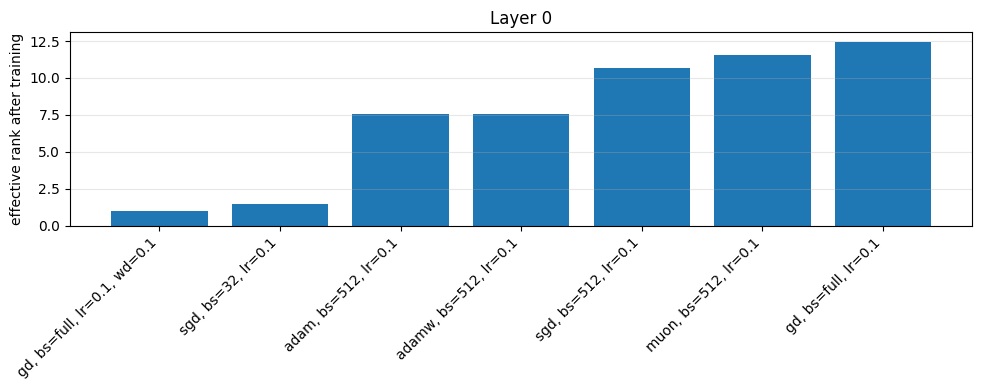

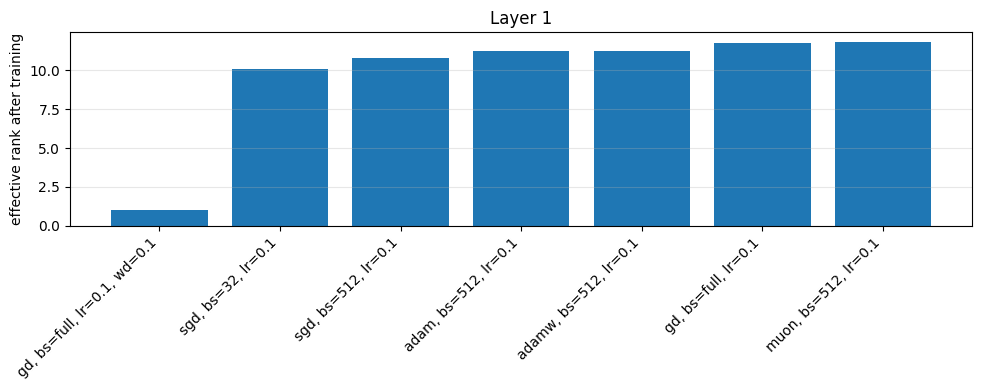

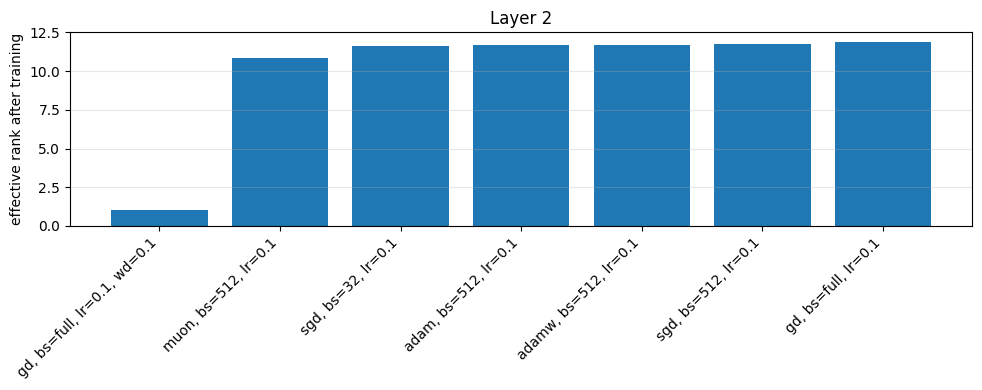

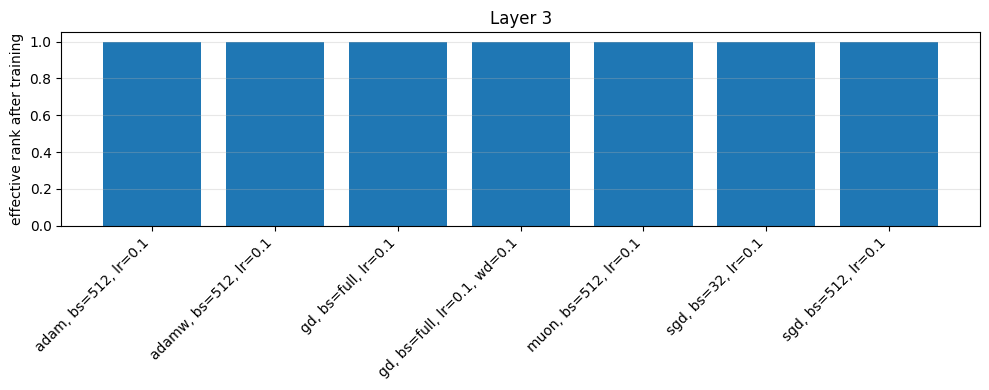

In [17]:
for layer in sorted(rank_df["layer"].unique()):
    layer_df = (
        rank_df[rank_df["layer"] == layer]
        .groupby("label", as_index=False)
        .agg(eff_rank_post=("eff_rank_post", "mean"))
        .sort_values("eff_rank_post")
    )

    plt.figure(figsize=(10, 4))
    plt.bar(layer_df["label"], layer_df["eff_rank_post"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("effective rank after training")
    plt.title(f"Layer {layer}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


## 10. Optional: compare only selected runs

Useful when the all-runs plot is too cluttered.


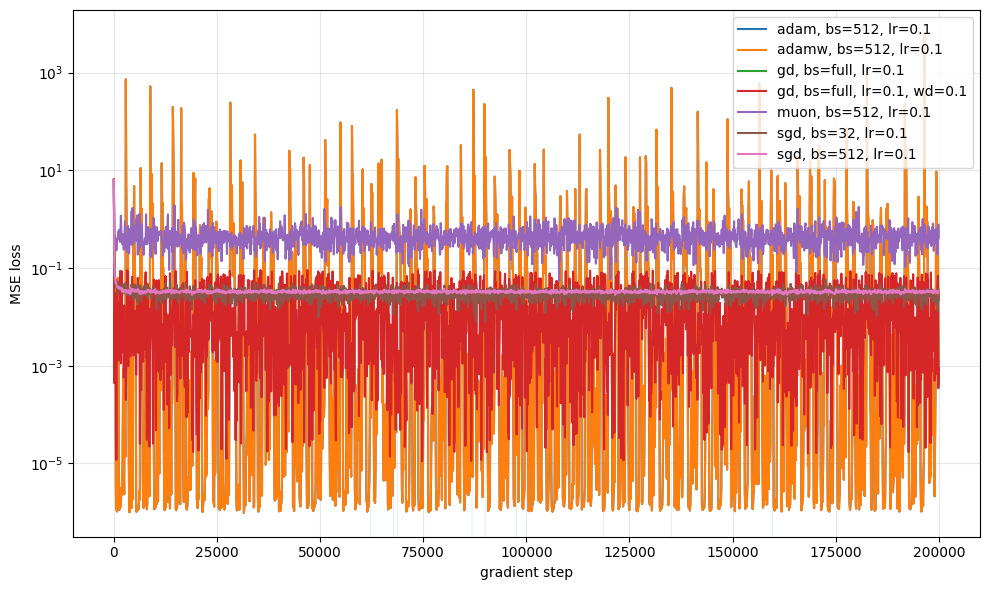

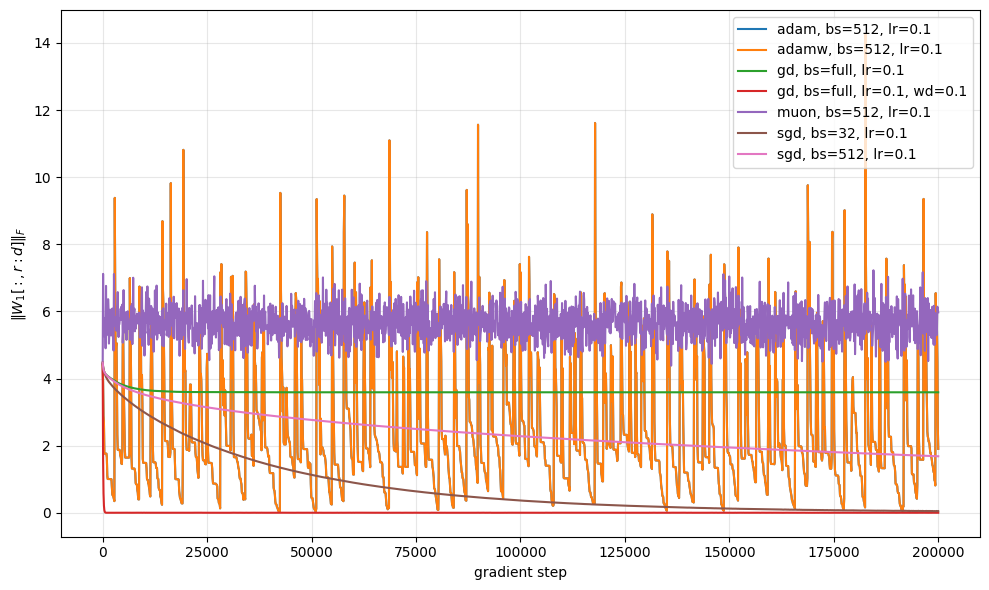

In [18]:
# Edit these substrings to filter runs.
SELECT = ["gd", "sgd32", "sgd512", "adam", "adamw", "muon"]

selected_runs = [
    run for run in runs
    if any(s in run["name"] for s in SELECT)
]

old_runs = runs
runs = selected_runs

plot_metric_curves("losses", "MSE loss", logy=True)
plot_metric_curves("irelnorms", r"$\|W_1[:, r:d]\|_F$", logy=False)

runs = old_runs


## Things to discuss from these plots

Good discussion questions:

1. Which methods get low loss?
2. Among low-loss methods, which get low irrelevant norm?
3. Does minibatch SGD beat full-batch GD on support selection?
4. Does weight decay mimic SGD's implicit regularization?
5. Do Adam/AdamW/Muon suppress irrelevant directions or just fit?
6. Are spectral changes correlated with support selection?
7. Does effective rank shrink more for some optimizers?
